In [2]:
import pandas as pd
from mpmath.libmp import normalize

In [39]:
def load_dataset():
    return pd.read_csv("YoutubeCommentsDataset.csv")

In [40]:
df.head()

,Comment,Sentiment,Comment
0,lets not forget that apple pay in 2014 require...,0,lets not forget that apple pay in 2014 require...
1,here in nz 50 of retailers don’t even have con...,-1,here in nz 50 of retailers don’t even have con...
2,i will forever acknowledge this channel with t...,1,i will forever acknowledge this channel with t...
3,whenever i go to a place that doesn’t take app...,-1,whenever i go to a place that doesn’t take app...
4,apple pay is so convenient secure and easy to ...,1,apple pay is so convenient secure and easy to ...


In [6]:
df["Sentiment"]

0         neutral
1        negative
2        positive
3        negative
4        positive
           ...   
18403    positive
18404    positive
18405     neutral
18406    positive
18407    positive
Name: Sentiment, Length: 18408, dtype: str

In [9]:
# Changing the sentiment into numbers for model
df["Sentiment"] = df["Sentiment"].map({"positive": 1, "negative": -1, "neutral": 0})


In [10]:
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,0
1,here in nz 50 of retailers don’t even have con...,-1
2,i will forever acknowledge this channel with t...,1
3,whenever i go to a place that doesn’t take app...,-1
4,apple pay is so convenient secure and easy to ...,1


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Comment    18364 non-null  str  
 1   Sentiment  18408 non-null  int64
dtypes: int64(1), str(1)
memory usage: 287.8 KB


In [12]:
df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [14]:
df[df["Comment"].isna()]

,Comment,Sentiment
602,NaN,-1
716,NaN,0
812,NaN,1
1021,NaN,1
1023,NaN,0
1041,NaN,1
1094,NaN,1
2443,NaN,1
3014,NaN,1
3235,NaN,1


In [15]:
df.dropna(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(490)

In [17]:
df[df.duplicated()]

,Comment,Sentiment
173,from all the stuff mentioned i have the dji mi...,1
518,happy independence day to ukraine and glory t...,-1
847,linus just turn the key lights 180 and bounce ...,1
848,dan continues to be my new favorite he has suc...,1
849,dan managing to set up his soldering station o...,1
...,...,...
18145,explore our free courses with completion certi...,0
18283,thanks for this video very neatly calmly expla...,1
18298,explore our free courses with completion certi...,0
18308,do you want to learn technology from me check ...,0


In [18]:
df.drop_duplicates(inplace=True)

In [41]:
df.duplicated().sum()

np.int64(0)

In [23]:
df[(df["Comment"].str.strip()== '')]

,Comment,Sentiment


In [24]:
df["Comment "] = df["Comment"].str.lower()

In [25]:
df[df["Comment"].apply(lambda x: x.endswith(" ") or x.startswith(" "))]

,Comment,Sentiment,Comment
20,linus just turn the key lights 180 and bounce ...,1,linus just turn the key lights 180 and bounce ...
30,unstoppable experiments with liquid nitrogen,1,unstoppable experiments with liquid nitrogen
35,കേരളത്തിൽ ആദ്യമായി പെട്രോളിനെ എയ്സ് ആക്കിയ m4...,0,കേരളത്തിൽ ആദ്യമായി പെട്രോളിനെ എയ്സ് ആക്കിയ m4...
38,തന്നെ തളർത്താൻ നോക്കിയവർ പോലും അവന്റെ ഉയർച്ചയി...,0,തന്നെ തളർത്താൻ നോക്കിയവർ പോലും അവന്റെ ഉയർച്ചയി...
39,എത്ര എടുത്താലും തീരാത്ത liquid nitrogen,0,എത്ര എടുത്താലും തീരാത്ത liquid nitrogen
...,...,...,...
18250,wow congratulations for starting such an amazi...,1,wow congratulations for starting such an amazi...
18278,omg such awesome day to day life examples give...,1,omg such awesome day to day life examples give...
18343,amazing explanation i loved the way you taught,1,amazing explanation i loved the way you taught
18349,idk if you realise the intensity of positive i...,1,idk if you realise the intensity of positive i...


In [ ]:
import langdetect

In [31]:
!pip install langdetect

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     -------------------------------------- 981.5/981.5 kB 8.2 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=1019153 sha256=5385e9412212fc87cdcd382ae5f87364ed20bea77b3642c2b68ddd52cdb115d7
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\13\60\5a\f2012969b3f7413b62b7b7063d6c9b45c93004a978cbe8ea2f
Successfully built langdetect



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from langdetect import detect, LangDetectException


def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False


df = df[df["Comment"].apply(is_english)]
df


,Comment,Sentiment,Comment
0,lets not forget that apple pay in 2014 require...,0,lets not forget that apple pay in 2014 require...
1,here in nz 50 of retailers don’t even have con...,-1,here in nz 50 of retailers don’t even have con...
2,i will forever acknowledge this channel with t...,1,i will forever acknowledge this channel with t...
3,whenever i go to a place that doesn’t take app...,-1,whenever i go to a place that doesn’t take app...
4,apple pay is so convenient secure and easy to ...,1,apple pay is so convenient secure and easy to ...
...,...,...,...
18402,back when i was learning to code i didn’t know...,0,back when i was learning to code i didn’t know...
18403,i really like the point about engineering tool...,1,i really like the point about engineering tool...
18404,i’ve just started exploring this field and thi...,1,i’ve just started exploring this field and thi...
18406,hey daniel just discovered your channel a coup...,1,hey daniel just discovered your channel a coup...


In [34]:
df.iloc[34]

Comment      guys a quick note that you do not need all the...
Sentiment                                                    0
Comment      guys a quick note that you do not need all the...
Name: 40, dtype: object

In [35]:
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['Comment'].str.contains(url_pattern, regex = True)]
comments_with_urls.head()

,Comment,Sentiment,Comment


In [37]:
comments_with_newline = df[df["Comment"].str.contains('\n')]
comments_with_newline.head()

,Comment,Sentiment,Comment


# EDA




In [42]:
 import matplotlib.pyplot as plt
 import seaborn as sns

<Axes: xlabel='Sentiment', ylabel='count'>

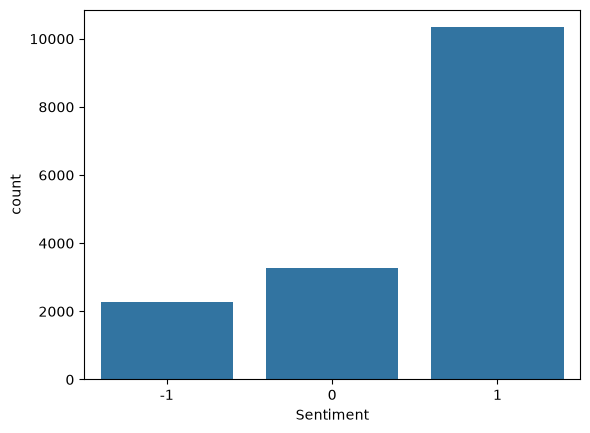

In [43]:
sns.countplot(data=df, x="Sentiment")

## Sentiment Distribution Analysis

This line of code analyzes the distribution of sentiment labels in the dataset:

- **`df['Sentiment']`** — selects the `Sentiment` column from the DataFrame
- **`.value_counts(normalize=True)`** — counts the occurrences of each unique value (`-1`, `0`, `1`) and returns them as **proportions** (fractions summing to 1) instead of raw counts
- **`.mul(100)`** — multiplies each proportion by 100 to convert to **percentages**
- **`.round(2)`** — rounds each percentage to **2 decimal places**

### Example Output:
| Sentiment | Percentage |
|-----------|------------|
| 1 (positive) | 45.32 |
| 0 (neutral)  | 30.15 |
| -1 (negative)| 24.53 |

This gives a quick overview of **how balanced** the dataset is across the three sentiment classes.
